In [1]:
import os
from qiskit import QuantumCircuit
import sinter
from ldpc.sinter_decoders import SinterBeliefFindDecoder, SinterBpOsdDecoder

from src.stabilizer_code import extract, to_qiskit, bb_code
from src.simulate import tostim, detector_error_model_gauge

from lib.TrapSIMD.sabre_iontrap import *
from lib.TrapSIMD.grid_iontrap import *

In [2]:
path = "./QEC-Code"

In [3]:
code_name = "BB-code"
stab_fname = os.path.join(path, f"{code_name}.stab")
bb_code(stab_fname)

qasm_fname = os.path.join(path, f"{code_name}.qasm")
is_CSS, is_ordered, stabilizers, logicals, dataNum = extract(stab_fname)
to_qiskit(qasm_fname, is_CSS, is_ordered, stabilizers, dataNum, iter=12)

(12, 72)


In [4]:
def gen_noise_profile2(p_trans = 2 * 10 ** (-4)):
    noise_profile = {
        "intra-move": p_trans,
        "intra-swap": p_trans,
        "inter-move": 2 * p_trans,
        "inter-swap": 4 * p_trans,
        "2q-gate": 18.3 * 10 ** (-4)
    }
    return noise_profile 

In [5]:
import time

# Fast debug profile (~4-5 minutes for task generation)
noise_list = [2e-4, 1e-4]
tasks = []

D = 5
L = 3
CZ = 3
draw_flag = False
rounds = 4

code_name = "BB-code"
stab_fname = os.path.join(path, f"{code_name}.stab")
qasm_fname = os.path.join(path, f"{code_name}.qasm")

t0 = time.time()
bb_code(stab_fname)
print(f"bb_code: {time.time() - t0:.1f}s")

t1 = time.time()
is_CSS, is_ordered, stabilizers, logicals, dataNum = extract(stab_fname)
to_qiskit(qasm_fname, is_CSS, is_ordered, stabilizers, dataNum, iter=rounds)
print(f"to_qiskit(iter={rounds}): {time.time() - t1:.1f}s")

t2 = time.time()
base_circ = QuantumCircuit.from_qasm_file(qasm_fname)
num_q = base_circ.num_qubits
num_s = base_circ.num_clbits
_, node_list = grid_compiler(D, L, CZ, base_circ, draw_flag)
print(f"grid_compiler(D={D}): {time.time() - t2:.1f}s")

for p in noise_list:
    tp = time.time()
    # BB path: build detector-only/gauge DEM to avoid non-deterministic
    # observable/detector validation failures in strict DEM generation.
    stim_circ = tostim(
        gen_noise_profile2(p),
        stabilizers,
        logicals,
        node_list,
        num_q,
        num_s,
        include_observables=False,
    )
    dem = detector_error_model_gauge(stim_circ)
    tasks.append(
        sinter.Task(
            circuit=stim_circ,
            detector_error_model=dem,
            skip_validation=True,
            json_metadata={"r": rounds, "p": p},
        )
    )
    print(f"tostim+dem p={p:.1e}: {time.time() - tp:.1f}s")

print(f"built {len(tasks)} tasks in {time.time() - t0:.1f}s")

(12, 72)
bb_code: 0.0s
to_qiskit(iter=4): 0.0s
grid_compiler(D=5): 154.8s
tostim+dem p=2.0e-04: 26.6s
tostim+dem p=1.0e-04: 24.4s
built 2 tasks in 205.8s


In [6]:
tasks[0].circuit

stim.Circuit('''
    R 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
    H 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107
    CX 18 108
    DEPOLARIZE2(0.00183) 18 108
    CX 21 111
    DEPOLARIZE2(0.00183) 21 111
    CX 24 114
    DEPOLARIZE2(0.00183) 24 114
    CX 25 115
    DEPOLARIZE2(0.00183) 25 115
    CX 27 117
    DEPOLARIZE2(0.00183) 27 117
    CX 29 119
    DEPOLARIZE2(0.00183) 29 119
    CX 32 122
    DEPOLARIZE2(0.00183) 32 122
    CX 33 123
    DEPOLARIZE2(0.00183) 33 123
    CX 34 124
    DEP

In [ ]:
# Quick-run profile: prioritize turnaround speed for BB+bposd
my_bp_method = "ms"
my_max_iter = 30
my_osd_method = "osd_cs"
my_osd_order = 1
my_ms_scaling_factor = 0

stats = sinter.collect(
    num_workers=2,
    tasks=tasks,
    decoders=["bposd"],
    custom_decoders={
        "bposd": SinterBpOsdDecoder(
            max_iter=my_max_iter,
            bp_method=my_bp_method,
            ms_scaling_factor=my_ms_scaling_factor,
            osd_method=my_osd_method,
            osd_order=my_osd_order,
        )
    },
    max_shots=3_000,
    print_progress=True,
)

Starting 2 workers...
2 tasks left:
  workers decoder  eta shots_left errors_seen json_metadata
        1   bposd 814m       2999           0 r=4,p=0.0002 
        1   bposd    ?       3000           0 r=4,p=0.0001 
2 tasks left:
  workers decoder  eta shots_left errors_seen json_metadata
        1   bposd 814m       2999           0 r=4,p=0.0002 
        1   bposd 814m       2999           0 r=4,p=0.0001 
2 tasks left:
  workers decoder  eta shots_left errors_seen json_metadata
        1   bposd 872m       2998           0 r=4,p=0.0002 
        1   bposd 814m       2999           0 r=4,p=0.0001 
2 tasks left:
  workers decoder  eta shots_left errors_seen json_metadata
        1   bposd 872m       2998           0 r=4,p=0.0002 
        1   bposd 873m       2998           0 r=4,p=0.0001 
2 tasks left:
  workers decoder  eta shots_left errors_seen json_metadata
        1   bposd 999m       2997           0 r=4,p=0.0002 
        1   bposd 873m       2998           0 r=4,p=0.0001 
2 tasks 

In [ ]:
# Decoder diagnostics: verify task shape and per-shot throughput
import time

print(f"tasks: {len(tasks)}")
for i, t in enumerate(tasks):
    print(
        f"task[{i}] dets={t.detector_error_model.num_detectors} "
        f"obs={t.detector_error_model.num_observables} p={t.json_metadata['p']}"
    )

# Tiny benchmark to isolate decoder speed (not for final statistics)
bench_task = tasks[0]

t0 = time.time()
bench_bposd = sinter.collect(
    num_workers=1,
    tasks=[bench_task],
    decoders=["bposd"],
    custom_decoders={
        "bposd": SinterBpOsdDecoder(
            max_iter=my_max_iter,
            bp_method=my_bp_method,
            ms_scaling_factor=my_ms_scaling_factor,
            osd_method=my_osd_method,
            osd_order=my_osd_order,
        )
    },
    max_shots=50,
    print_progress=False,
)
print(f"bposd benchmark: {time.time() - t0:.2f}s for 50 shots")
print(bench_bposd[0])

# Baseline speed with pymatching on same task (if available)
t1 = time.time()
bench_pm = sinter.collect(
    num_workers=1,
    tasks=[bench_task],
    decoders=["pymatching"],
    max_shots=50,
    print_progress=False,
)
print(f"pymatching benchmark: {time.time() - t1:.2f}s for 50 shots")
print(bench_pm[0])

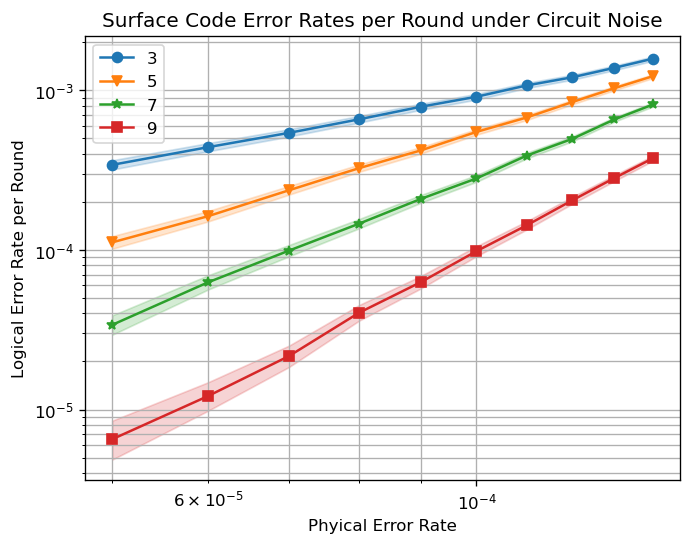

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda stats: stats.json_metadata['p'],
    failure_units_per_shot_func=lambda stats: stats.json_metadata['r'],
)
ax.loglog()
ax.set_title("Surface Code Error Rates per Round under Circuit Noise")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Round")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  